In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("car_fuel_efficiency.csv")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [2]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [3]:
df = df.fillna(0)
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,0.0,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,0.0,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split

seed = 1

df_train_val, df_test  = train_test_split(df, test_size=.2, random_state=seed)
df_train, df_val = train_test_split(df_train_val, test_size=.25, random_state=seed)

target = "fuel_efficiency_mpg"

df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

y_train, y_val, y_test = df_train[target], df_val[target], df_test[target]

del df_train[target]
del df_val[target]
del df_test[target]

dv = DictVectorizer(sparse=False)
dv.fit(df_train.to_dict(orient="records"))

prep = lambda d: pd.DataFrame(dv.transform(d.to_dict(orient="records")), columns=dv.get_feature_names_out()) # .round().astype('int')
df_train = prep(df_train)
df_val = prep(df_val)
df_test = prep(df_test)


In [5]:
df_train.head()

,acceleration,drivetrain=All-wheel drive,drivetrain=Front-wheel drive,engine_displacement,fuel_type=Diesel,fuel_type=Gasoline,horsepower,model_year,num_cylinders,num_doors,origin=Asia,origin=Europe,origin=USA,vehicle_weight
0,13.9,0.0,1.0,120.0,0.0,1.0,169.0,2005.0,5.0,-1.0,0.0,0.0,1.0,2966.679505
1,17.1,0.0,1.0,200.0,1.0,0.0,143.0,2013.0,3.0,-1.0,1.0,0.0,0.0,2950.822121
2,17.4,1.0,0.0,180.0,0.0,1.0,180.0,2007.0,6.0,0.0,0.0,0.0,1.0,3078.221669
3,0.0,1.0,0.0,280.0,1.0,0.0,174.0,2016.0,5.0,0.0,0.0,0.0,1.0,2797.991793
4,16.3,0.0,1.0,250.0,1.0,0.0,133.0,2010.0,4.0,-1.0,0.0,0.0,1.0,2362.426930


# Q1

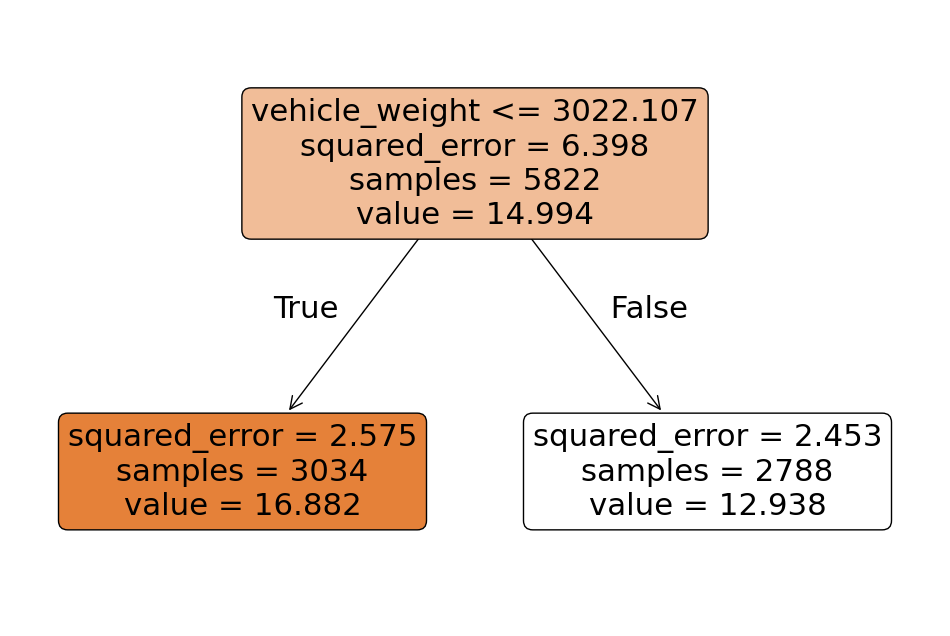

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

dt = DecisionTreeRegressor(max_depth=1)
dt.fit(df_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(dt, 
          filled=True, 
          feature_names=df_train.columns,
          rounded=True)
plt.show()

# Q2

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error 

rmse = lambda x,y: mean_squared_error(x,y)**.5


forest = RandomForestRegressor(
    n_estimators=10,
    random_state=seed,
    n_jobs=-1
)

forest.fit(df_train,y_train)
score = rmse(forest.predict(df_val), y_val)

score

0.4599777557336148

# Q3

In [8]:
n = range(10,201,10)
estrs = []
scores = []
for i in n:
    forest = RandomForestRegressor(
        n_estimators=i,
        random_state=seed,
        n_jobs=-1
    )
    
    forest.fit(df_train,y_train)
    score = rmse(forest.predict(df_val), y_val)
    estrs.append(i)
    scores.append(score)

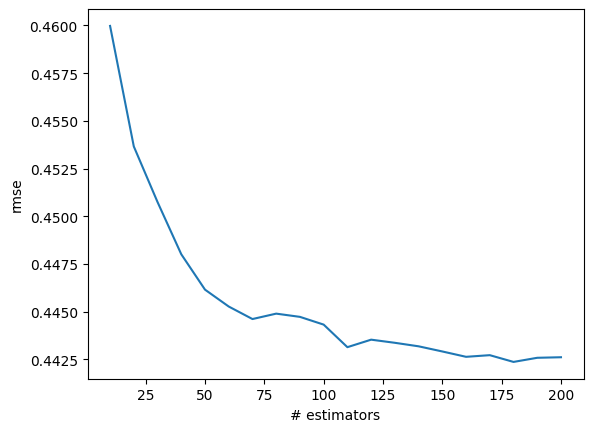

In [9]:
plt.plot(estrs,scores)
plt.xlabel('# estimators')
plt.ylabel('rmse')
plt.show()

In [16]:
sorted(zip(estrs,scores), key=lambda v:v[0])

[(10, 0.4599777557336148),
 (20, 0.45365906507838477),
 (30, 0.45074274602790043),
 (40, 0.44800679363046675),
 (50, 0.4461512805507994),
 (60, 0.4452658337959235),
 (70, 0.44460982491385304),
 (80, 0.44489319803906885),
 (90, 0.4447241129599527),
 (100, 0.4443178455925074),
 (110, 0.44313500906534525),
 (120, 0.4435285723898764),
 (130, 0.4433641780708843),
 (140, 0.4431801001185646),
 (150, 0.442909875717056),
 (160, 0.44262936541807835),
 (170, 0.4427157028806332),
 (180, 0.44236168144620613),
 (190, 0.4425785032007027),
 (200, 0.44260685365230207)]

# Q4

In [11]:
max_depth = [10, 15, 20, 25]
n_estimators = range(10,201,10)

params = [{"max_depth":md, "n_estimators":ne} for md in max_depth for ne in n_estimators]

results = []
for p in params:
    forest = RandomForestRegressor(
        random_state=seed,
        n_jobs=-1,
        **p
    )
    forest.fit(df_train,y_train)
    score = rmse(forest.predict(df_val), y_val)
    results.append([p["max_depth"], p["n_estimators"], score])

results = pd.DataFrame(results , columns=["max_depth","n_estimators","score"])

In [12]:
results.groupby('max_depth')['score'].mean()
# results.sort_values('score', ascending=True).head()

max_depth
10    0.442321
15    0.445060
20    0.445644
25    0.445661
Name: score, dtype: float64

# Q5

In [13]:

forest = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1 
)
forest.fit(df_train,y_train)

sorted(list(zip(forest.feature_importances_,df_train.columns)), key = lambda v: v[0])


[(np.float64(0.0003118420847931972), 'drivetrain=Front-wheel drive'),
 (np.float64(0.0003366719883675566), 'fuel_type=Gasoline'),
 (np.float64(0.0003436934113118486), 'fuel_type=Diesel'),
 (np.float64(0.0003818097503064216), 'drivetrain=All-wheel drive'),
 (np.float64(0.0004761030460744537), 'origin=Asia'),
 (np.float64(0.0005203580827405701), 'origin=Europe'),
 (np.float64(0.0005551519590829983), 'origin=USA'),
 (np.float64(0.0015911330645071602), 'num_doors'),
 (np.float64(0.002358670936092339), 'num_cylinders'),
 (np.float64(0.003182298414589243), 'model_year'),
 (np.float64(0.003269323417164296), 'engine_displacement'),
 (np.float64(0.011470716492980806), 'acceleration'),
 (np.float64(0.016040214819390435), 'horsepower'),
 (np.float64(0.9591620125325987), 'vehicle_weight')]

# Q6

In [14]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}


In [15]:
import xgboost as xgb

dtrain = xgb.DMatrix(df_train, label = y_train)
dval = xgb.DMatrix(df_val, label = y_val)

for eta in [0.3, 0.1]:
    xgb_params['eta']=eta
    model = xgb.train(xgb_params, dtrain, num_boost_round=100)
    print(f"{eta=}, rmse={rmse(model.predict(dval), y_val)}")


eta=0.3, rmse=0.45017755678087246
eta=0.1, rmse=0.42622800553359225
